# Week 3 Day 3 — Random Forests

## What I built:
- Simulated bagging manually — 5 bootstrap trees averaged
- Compared Single Tree vs Bagging vs Random Forest
- Tuned n_estimators using OOB score — best: 200
- Tuned max_features — sqrt beats None (all features)
- RandomizedSearchCV — 20 combinations, found best params
- Applied to Titanic — 4 Kaggle submissions

## Key concepts:

**Bagging:**
- Bootstrap sample (with replacement) per tree
- Average predictions — reduces variance
- Each tree sees ~63% of data, ~37% OOB

**Random Forest vs Bagging:**
- Bagging: different data per tree
- Random Forest: different data + random feature subset per split
- More decorrelated trees = better ensemble

**OOB score:**
- Free validation using the 37% not seen by each tree
- No separate val set needed
- Reliable performance estimate

**Tuning results:**
- Best params: n_estimators=300, max_depth=5,
  max_features=sqrt, min_samples_leaf=4
- Constrained depth crucial — depth=None overfit badly

## Kaggle scores:
v1 Logistic Regression : 0.78229
v2 Titanic Pipeline    : 0.77511
v3 RF depth=None       : 0.76794 ← overfit
v4 RF depth=5          : 0.78468 ← new best ✅

# Simulate bagging manually:

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=10,
                           n_informative=5, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# manual bagging - 5 trees
n_trees=5
trees = []

for i in range(n_trees):
    #bootstrap sample - sample with replacement
    indices = np.random.choice(len(X_train), size = len(X_train), replace=True)
    X_boot = X_train[indices]
    y_boot  = y_train[indices]

    # train one tree
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_boot, y_boot)
    trees.append(tree)

# aggregate predictions — majority vote
all_preds = np.array([tree.predict(X_val) for tree in trees])
manual_preds = np.round(all_preds.mean(axis=0)).astype(int)
manual_acc = np.mean(manual_preds == y_val)

# compare to sklearn BaggingClassifier
bagging = BaggingClassifier(n_estimators=5, random_state=42)
bagging.fit(X_train, y_train)
bagging_acc = bagging.score(X_val, y_val)


# single tree for comparison
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
single_acc = single_tree.score(X_val, y_val)

print("=" * 45)
print("   BAGGING DEMONSTRATION")
print("=" * 45)
print(f"  Single tree    : {single_acc:.4f}")
print(f"  Manual bagging : {manual_acc:.4f}")
print(f"  Sklearn bagging: {bagging_acc:.4f}")
print("=" * 45)

   BAGGING DEMONSTRATION
  Single tree    : 0.8800
  Manual bagging : 0.8900
  Sklearn bagging: 0.9200


# Random Forest vs Bagging:

In [2]:
from sklearn.ensemble import RandomForestClassifier

# compare single tree, bagging, random forest
from sklearn.model_selection import cross_val_score, StratifiedKFold

skfold = StratifiedKFold(n_splits=5)

models = {
    'Single Tree'    : DecisionTreeClassifier(random_state=42),
    'Bagging'        : BaggingClassifier(n_estimators=100, random_state=42),
    'Random Forest'  : RandomForestClassifier(n_estimators=100, random_state=42)
}

print("=" * 50)
print("   SINGLE TREE vs BAGGING vs RANDOM FOREST")
print("=" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skfold, scoring='accuracy')
    print(f"  {name:20} : {scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 50)

   SINGLE TREE vs BAGGING vs RANDOM FOREST
  Single Tree          : 0.8620 ± 0.0214
  Bagging              : 0.9020 ± 0.0204
  Random Forest        : 0.9100 ± 0.0303


# Tune n_estimators with OOB score:

  n_estimators=  10 → OOB score: 0.8625
  n_estimators=  50 → OOB score: 0.8950
  n_estimators= 100 → OOB score: 0.9000
  n_estimators= 200 → OOB score: 0.9175
  n_estimators= 500 → OOB score: 0.9050


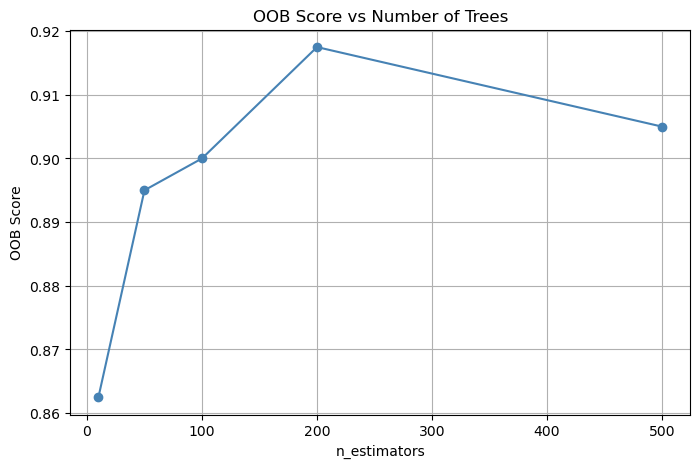


Best n_estimators : 200
Best OOB score    : 0.9175


In [3]:
n_estimators_list = [10,50,100,200,500]
oob_scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    print(f"  n_estimators={n:4d} → OOB score: {rf.oob_score_:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, oob_scores, marker='o', color='steelblue')
plt.title('OOB Score vs Number of Trees')
plt.xlabel('n_estimators')
plt.ylabel('OOB Score')
plt.grid(True)
plt.savefig('oob_score.png', dpi=150, bbox_inches='tight')
plt.show()

best_n = n_estimators_list[np.argmax(oob_scores)]
print(f"\nBest n_estimators : {best_n}")
print(f"Best OOB score    : {max(oob_scores):.4f}")

# Tune max_features:

In [4]:
max_features_list = ['sqrt', 'log2', 0.3, 0.5, None]
results = []

print("=" * 50)
print("   MAX FEATURES TUNING")
print("=" * 50)

for mf in max_features_list:
    rf = RandomForestClassifier(n_estimators=200,
                                max_features=mf,
                                oob_score=True,
                                random_state=42)
    rf.fit(X_train, y_train)
    results.append(rf.oob_score_)
    print(f"  max_features={str(mf):6} → OOB: {rf.oob_score_:.4f}")

print("=" * 50)
best_mf = max_features_list[np.argmax(results)]
print(f"  Best max_features : {best_mf}")
print("=" * 50)

   MAX FEATURES TUNING
  max_features=sqrt   → OOB: 0.9175
  max_features=log2   → OOB: 0.9175
  max_features=0.3    → OOB: 0.9175
  max_features=0.5    → OOB: 0.9125
  max_features=None   → OOB: 0.8850
  Best max_features : sqrt


# Now apply Random Forest to Titanic:

In [5]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

df = pd.read_csv('train.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)

num_cols = ['Age', 'Fare', 'FamilySize', 'Title']
cat_cols = ['Sex', 'Embarked', 'Pclass']
X = df[num_cols + cat_cols]
y = df['Survived']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# compare all models so far
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

skfold = StratifiedKFold(n_splits=5)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200,
                                                   max_features='sqrt',
                                                   random_state=42)
}

print("=" * 50)
print("   MODEL COMPARISON — Titanic")
print("=" * 50)
for name, model in models.items():
    pipe   = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skfold, scoring='accuracy')
    print(f"  {name:22} : {scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 50)

   MODEL COMPARISON — Titanic
  Logistic Regression    : 0.8114 ± 0.0144
  Decision Tree          : 0.8193 ± 0.0261
  Random Forest          : 0.8104 ± 0.0279


# Tuning of Random Forest:

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# param grid to search
param_grid = {
    'model__n_estimators'  : [100, 200, 300],
    'model__max_depth'     : [3, 5, 7, None],
    'model__max_features'  : ['sqrt', 'log2'],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(
    rf_pipe, param_grid,
    n_iter=20, cv=skfold,
    scoring='accuracy',
    random_state=42, n_jobs=-1
)
search.fit(X, y)

print("=" * 50)
print("   TUNED RANDOM FOREST")
print("=" * 50)
print(f"  Best score  : {search.best_score_:.4f}")
print(f"  Best params : {search.best_params_}")
print("=" * 50)

   TUNED RANDOM FOREST
  Best score  : 0.8339
  Best params : {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}


# Submit to Kaggle with tuned Random Forest:

In [7]:
test_df = pd.read_csv('test.csv')

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone']    = (test_df['FamilySize'] == 1).astype(int)
test_df['Title']      = test_df['Name'].apply(
                            lambda name: name.split(',')[1]
                                             .split('.')[0].strip())
test_df['Title']      = test_df['Title'].map({
                            'Mr': 0, 'Miss': 1, 'Mrs': 2,
                            'Master': 3}).fillna(4)
test_df['Fare']       = test_df['Fare'].fillna(test_df['Fare'].median())

X_test = test_df[num_cols + cat_cols]

# fit best model on full train data
best_model = search.best_estimator_
best_model.fit(X, y)
predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    predictions
})
submission.to_csv('submission_v3.csv', index=False)
print("Submission v3 saved!")

Submission v3 saved!


# Fix — constrain the tree depth:

In [8]:
from sklearn.ensemble import RandomForestClassifier

# force max_depth=5 — prevents overfitting
rf_constrained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        max_features='sqrt',
        min_samples_leaf=4,
        random_state=42
    ))
])

rf_constrained.fit(X, y)
predictions = rf_constrained.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    predictions
})
submission.to_csv('submission_v4.csv', index=False)
print("Submission v4 saved!")

Submission v4 saved!
